In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
# Usage
base_dir = "../experiment14[depol-time-evo-noisy_variousorderzne_tmax_20]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)
EXACT_SOL: float = -8.566772233505624

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['VQE', 'ZNE-single-var', 'VQE_noiseoff'])

In [4]:
RAW_SIM_DATA["ZNE-single-var"].keys()

dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

In [5]:
def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}

    # 'data' directly contains VQE, VQE_noiseoff, ZNE-single-var
    content = raw_data.get("data", raw_data)

    # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
    nf_folder = content.get("VQE_noiseoff", {})
    nf_costs = []
    for k, run in nf_folder.items():
        if not run or "REDUNDANT" in k or "output" not in run:
            continue
        try:
            nf_costs.append(run["output"]["optimized_minimum_cost"][0])
        except (KeyError, IndexError, TypeError):
            continue

    nf_stats = {
        "mean": float(np.mean(nf_costs)) if nf_costs else None,
        "std":  float(np.std(nf_costs))  if nf_costs else None
    }
    print(f"✅ VQE_noiseoff: {len(nf_costs)} runs aggregated, mean={nf_stats['mean']}")

    # --- 2. Processing ZNE Subfolders (ric2, ric3, ...) ---
    zne_folder = content.get("ZNE-single-var", {})
    print(f"✅ ZNE labels found: {list(zne_folder.keys())}")

    for label, runs in zne_folder.items():
        ext_vals, all_y_curves = [], []
        noise_levels = None
        tmax = None

        for k, run in runs.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue

            zne_vals  = run["output"].get("zne_values", {})
            others    = zne_vals.get("others", {})
            tmax      = run["config"]["ansatz"]["ugate"]["time"]["max"]
            current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
            current_n = others.get("sorted_noise")            or zne_vals.get("sorted_noise")
            ext_val   = zne_vals.get("extrapolated_value")

            if current_y and current_n and ext_val is not None:
                ext_vals.append(ext_val)
                all_y_curves.append(current_y)
                if noise_levels is None:
                    noise_levels = current_n
            else:
                print(f"⚠️ Skipping {label}/{k}: Missing required keys.")

        # --- 3. Final Formatting ---
        if ext_vals and all_y_curves:
            y_array = np.array(all_y_curves)
            processed[label] = {
                "noise_type":     "depolarizing",
                "tmax":           tmax,
                "exact_sol":      EXACT_SOL,
                "sorted_noise":   noise_levels,
                "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                "zne_mean":       float(np.mean(ext_vals)),
                "zne_std":        float(np.std(ext_vals)),
                "mean_noise_off": nf_stats["mean"],
                "std_noise_off":  nf_stats["std"]
            }
            print(f"✅ {label}: {len(ext_vals)} runs processed")
        else:
            print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [6]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

✅ VQE_noiseoff: 10 runs aggregated, mean=-8.435520319786601
✅ ZNE labels found: ['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2']
✅ ric6: 10 runs processed
✅ ric7: 10 runs processed
✅ ric5: 10 runs processed
✅ ric3: 10 runs processed
✅ ric4: 10 runs processed
✅ ric2: 10 runs processed


dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

In [7]:
PROCESSED_SIM_DATA.keys()

dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

In [8]:
# Output directory to save plot figures
OUTPUT_DIR = "master-reports"
COLORS = {
    "noisy":      "#1f77b4",
    "zne":        "#ff7f0e",
    "exact":      "#d62728",
    "noise_free": "#0000ff",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'depolarizing',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47, 81, 115],
 'mean_exp_vals': [-6.201563991993811,
                   -2.9953345060519347,
                   -1.5150182758416424,
                   -0.7925463234618297],
 'std_exp_vals': [0.11133119201572951,
                  0.1744840700806796,
                  0.14562284379920612,
                  0.1073737011248071],
 'zne_mean': -8.08675111458275,
 'zne_std': 0.051464454626421345,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368}


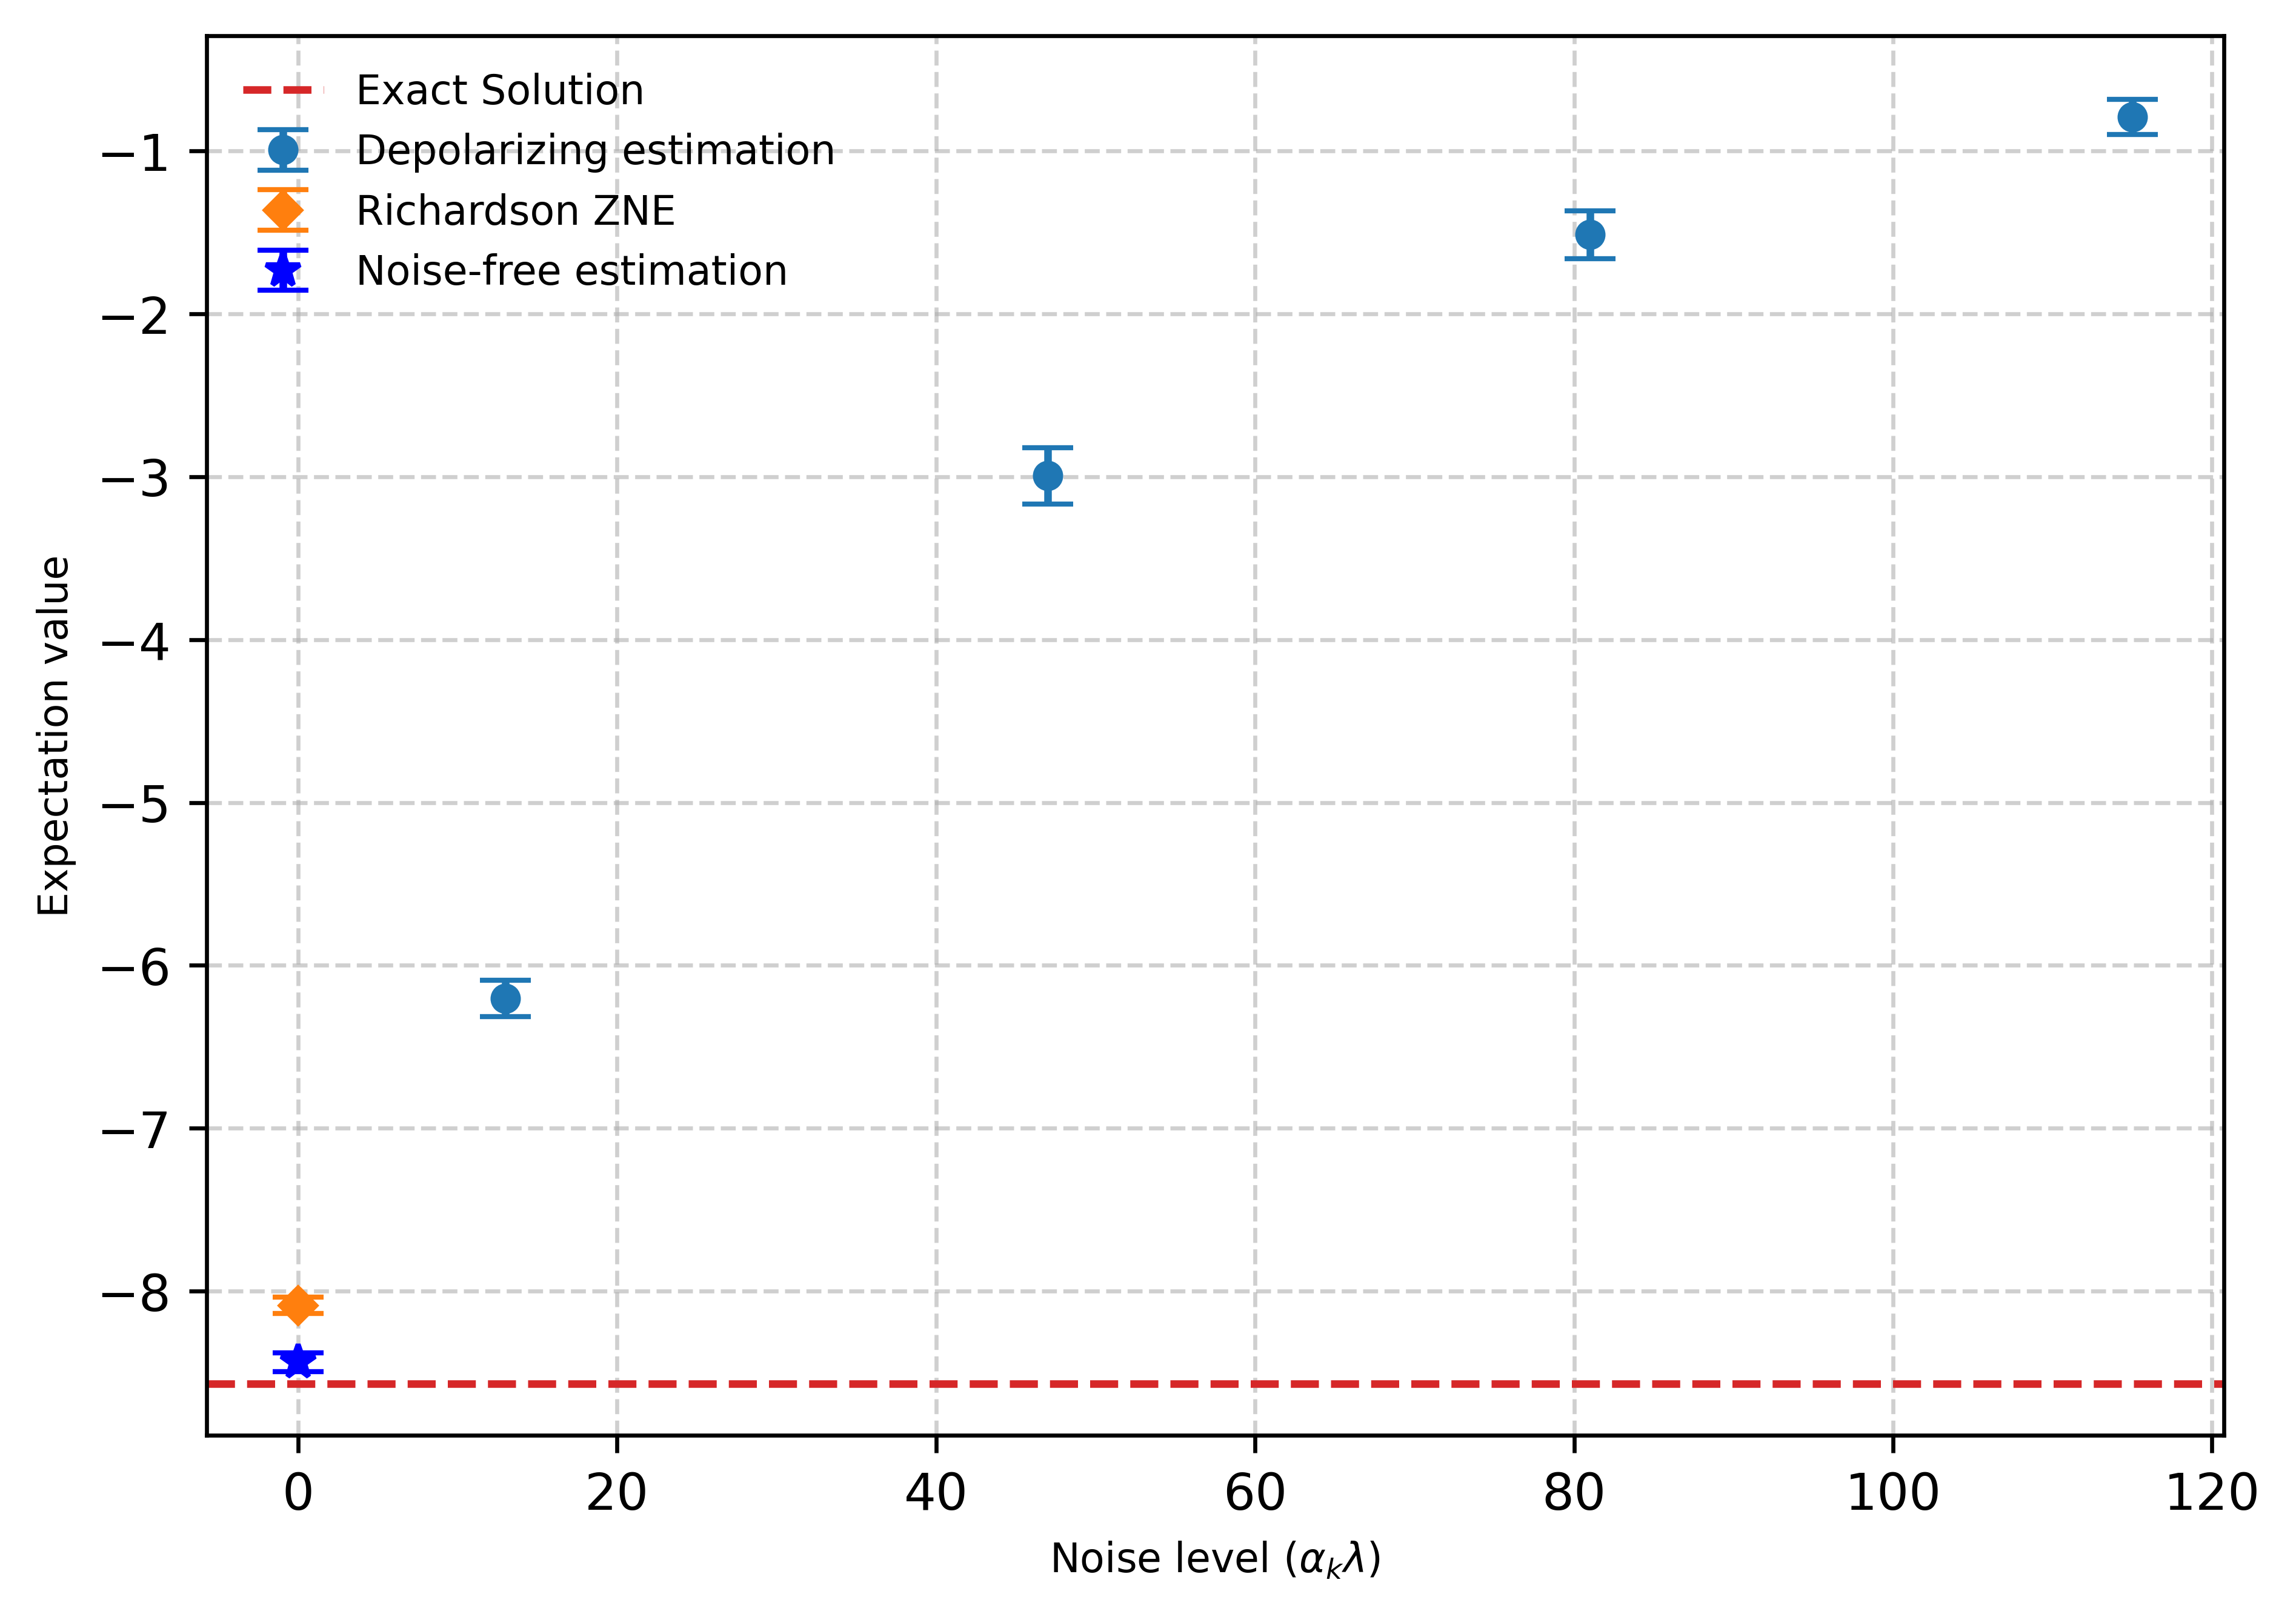

In [9]:
fig = plot_single_zne(
    data=PROCESSED_SIM_DATA["ric4"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

In [10]:
type(PROCESSED_SIM_DATA.keys())

dict_keys

✅ Figure saved as (in 'master-reports' folder): zne_grid_exp01.png


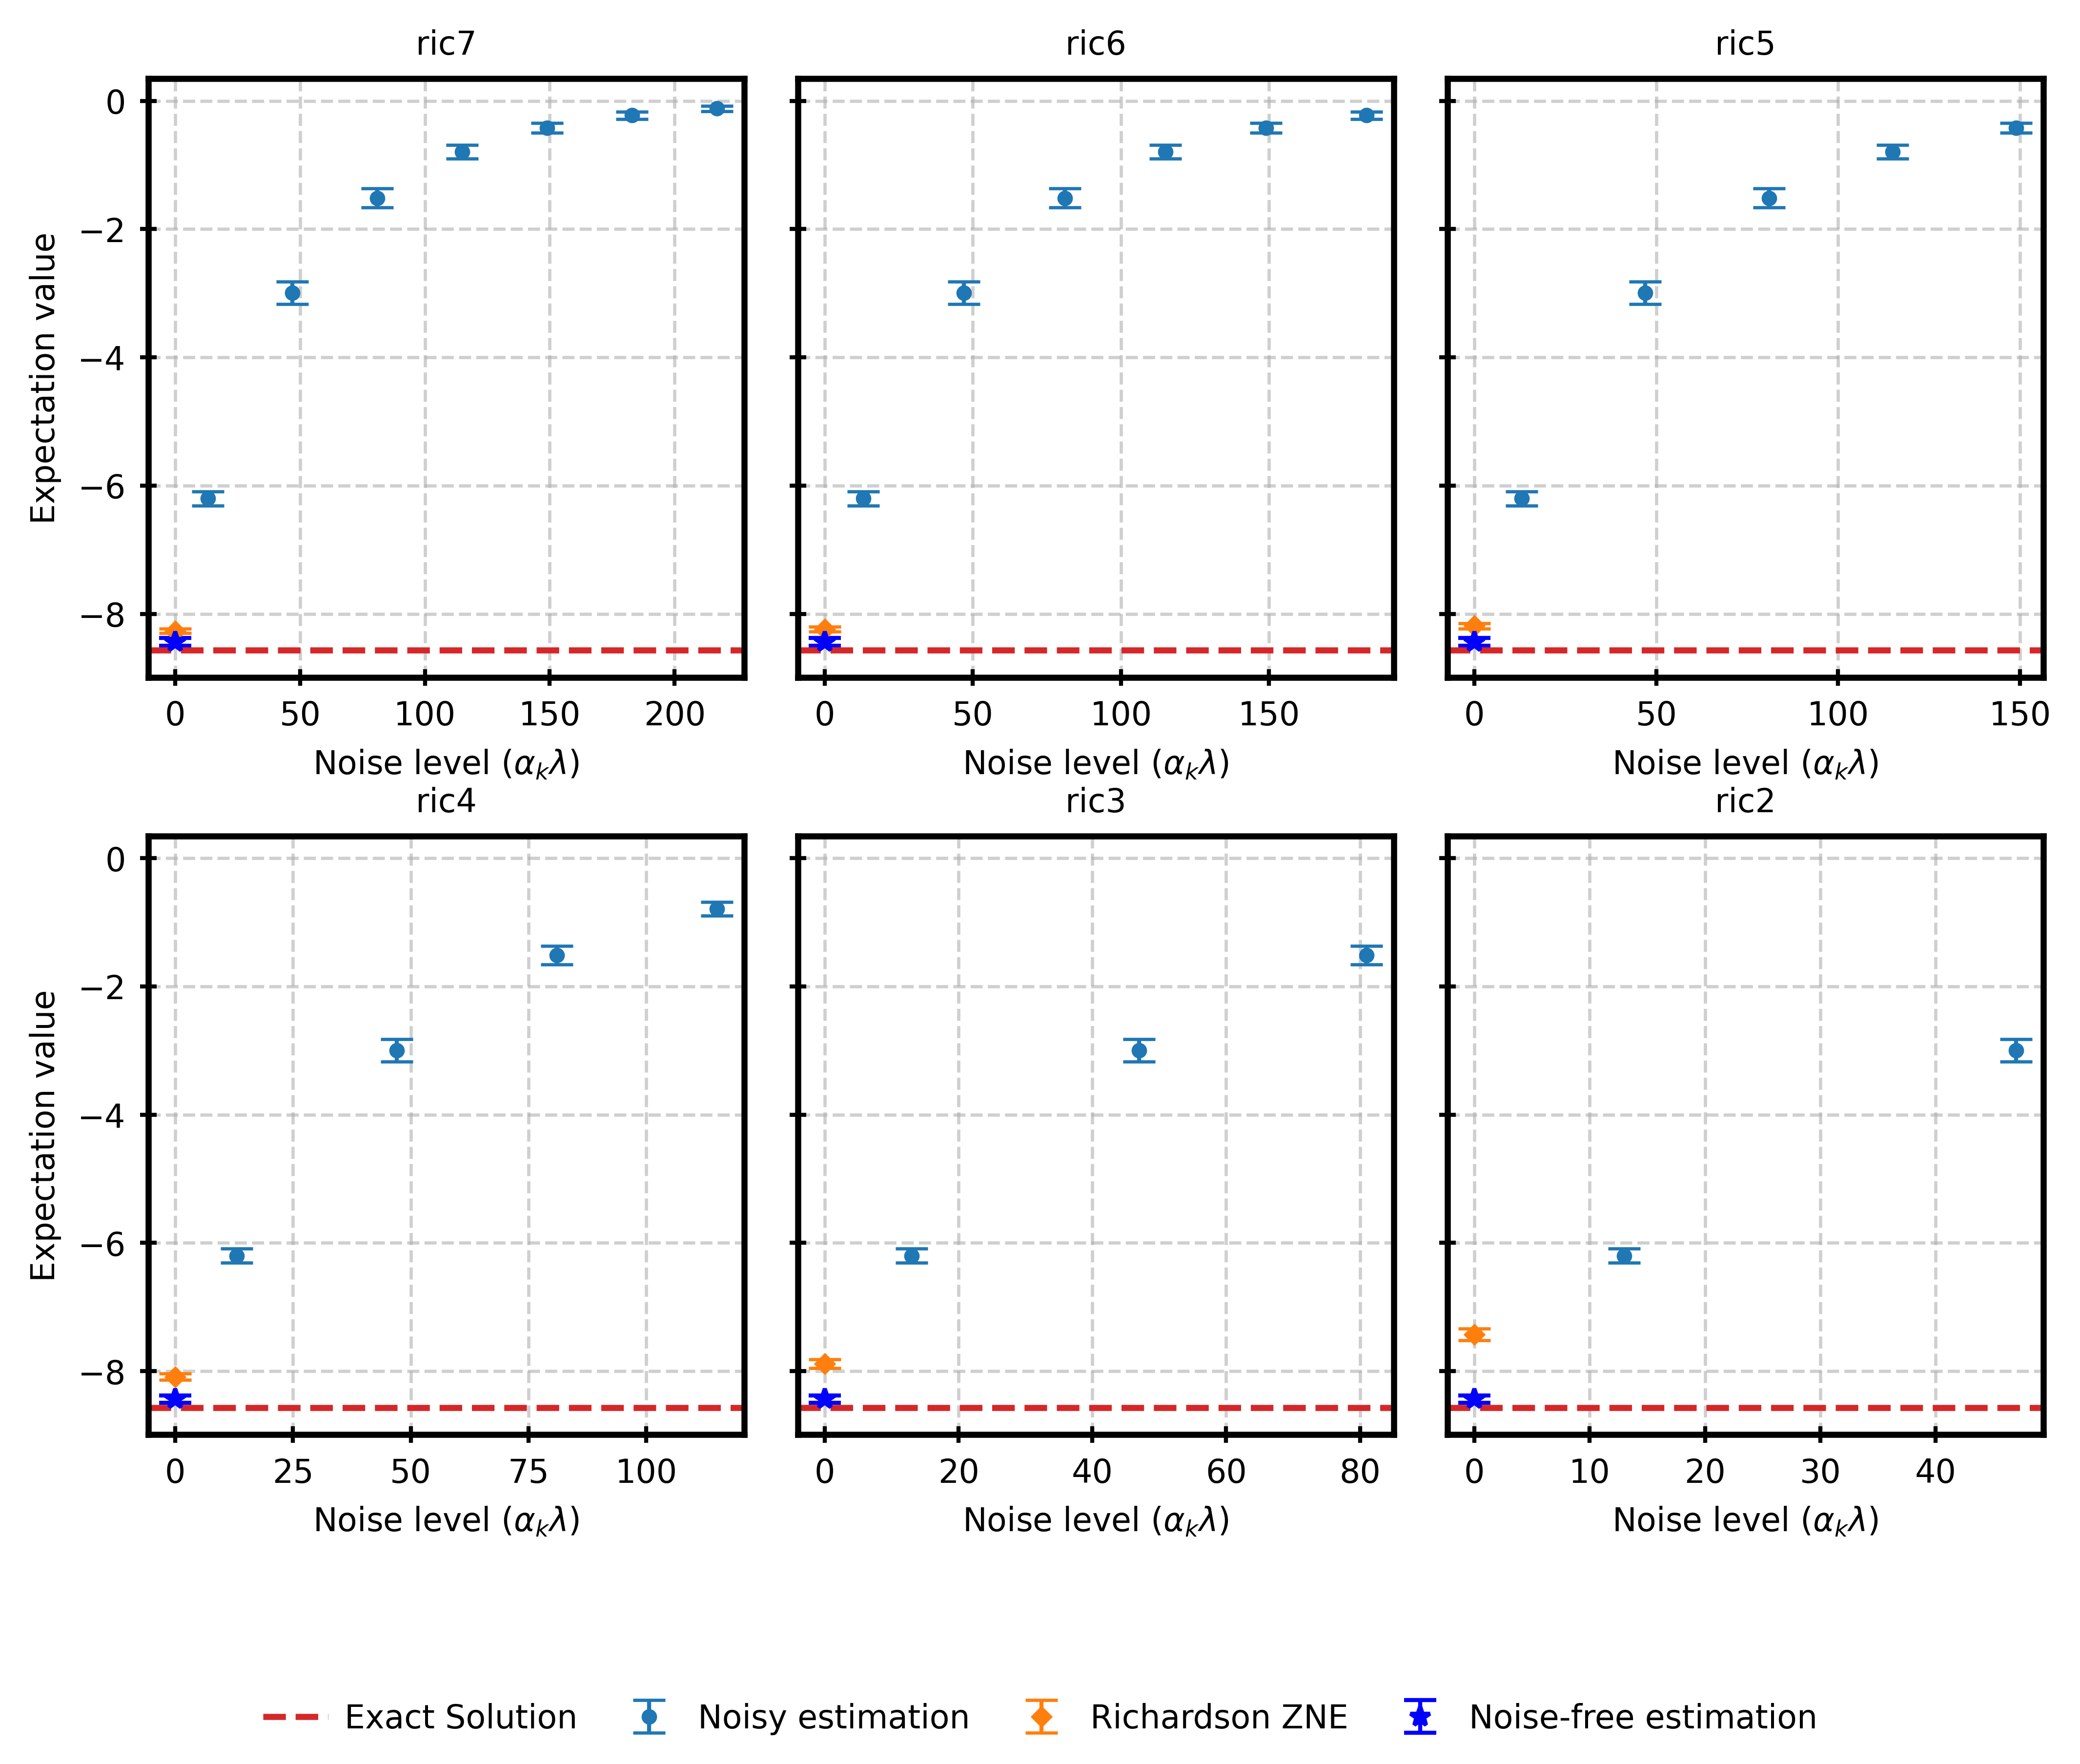

In [18]:
# pick which subcategories to include and in which order
subkeys = ["ric7", "ric6", "ric5", "ric4", "ric3", "ric2"]  # or specify a subset like ["ric2", "ric3", "ric4", "ric5", "ric6"]

data_list   = [PROCESSED_SIM_DATA[k] for k in subkeys]
plot_titles = subkeys   # or any custom labels you want per panel

fig = plot_multi_zne(
    data_list      = data_list,
    plot_titles    = plot_titles,
    plot_colors    = COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    tick_fontsize = TICK_FONT_SIZE,
    marker_size = 3,
    legend_fontsize = LEGEND_FONT_SIZE,
    plot_file_name = "zne_grid_exp01",
    output_dir     = OUTPUT_DIR,
    extrapol_target= 0,
    ncols          = 3,
    figsize=(7.16, 6.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
    sharex         = False,
    sharey         = True,
    show_legend    = True,
    global_legend  = True,       # single shared legend at bottom
    #legend_loc     = "lower center",
    save_format    = "png",
    show_plot      = True,
    print_data     = False,
)